In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# import os
# import gzip
# import shutil

# # Directory containing gzipped files
# TRACES_DIR = "traces"

# # Check if the directory exists
# if os.path.isdir(TRACES_DIR):
#     print(f"Extracting all .gz files in the {TRACES_DIR} directory...")
    
#     # Loop through all .gz files in the directory
#     for filename in os.listdir(TRACES_DIR):
#         if filename.endswith(".gz"):
#             gz_file_path = os.path.join(TRACES_DIR, filename)
#             extracted_file_path = os.path.join(TRACES_DIR, filename[:-3])  # Remove .gz extension
            
#             print(f"Extracting {gz_file_path}...")
#             with gzip.open(gz_file_path, 'rb') as gz_file:
#                 with open(extracted_file_path, 'wb') as extracted_file:
#                     shutil.copyfileobj(gz_file, extracted_file)
            
#             # Optionally, delete the original .gz file after extraction
#             os.remove(gz_file_path)
    
#     print("Extraction complete.")
# else:
#     print(f"Directory {TRACES_DIR} does not exist.")

In [3]:
# import multiple csv files and combine them into one dataframe

df = pd.DataFrame()
file_names = ['1.csv', '10.csv',
              '100.csv', '102.csv', '103.csv', '104.csv', '105.csv', '106.csv']

for file_name in file_names:
    df_temp = pd.read_csv('traces/'+file_name)
    df = pd.concat([df, df_temp])

In [4]:
df

,timestamp,traceid,service,rpc_id,rpctype,um,uminstanceid,interface,dm,dminstanceid,rt
0,39089838,T_22576012893,S_153587416,0.1.1,db,MS_71712,MS_71712_POD_88,mJxUT-THwr,MS_27421,UNKNOWN,0.0
1,39089838,T_22576012893,S_153587416,0.1,rpc,MS_58845,MS_58845_POD_0,xOuy6-80Vt,MS_71712,MS_71712_POD_88,1.0
2,39089838,T_22576012893,S_153587416,0.1.2,db,MS_71712,MS_71712_POD_88,GOtlFS2se9:TDDL_QUERY,MS_37640,MS_37640_POD_17,1.0
3,39228752,T_12738187599,S_101270041,0.1,http,UNKNOWN,UNAVAILABLE,sOyhVROgeN,MS_4653,MS_4653_POD_10,1.0
4,39091562,T_11106192397,S_32048416,0.1,rpc,MS_9570,MS_9570_POD_11,l1UOM53a6T,MS_20664,MS_20664_POD_186,24.0
...,...,...,...,...,...,...,...,...,...,...,...
1615221,33218437,T_5176567082,S_7224478,0.1.2.6.2,db,MS_57628,MS_57628_POD_14,mJxUT-THwr,MS_27421,UNKNOWN,0.0
1615222,33294554,T_4887361580,S_156482560,0.1,http,UNKNOWN,UNAVAILABLE,bHiJXTZtx1,MS_40912,MS_40912_POD_266,1.0
1615223,33294554,T_4887361580,S_156482560,0.1.1,mc,MS_40912,MS_40912_POD_266,ZaYxnA3U_f,MS_58269,MS_58269_POD_33,0.0
1615224,33246815,T_9859950430,S_102107819,0.1,http,UNKNOWN,UNAVAILABLE,uK1veKO_pX,MS_67915,MS_67915_POD_130,3.0


In [5]:
df['um'].value_counts()[:5]

um
UNKNOWN        1699199
USER           1054473
UNAVAILABLE     345650
MS_15934        307656
MS_53154        261954
Name: count, dtype: int64

In [6]:
# Filter only request that upstream microservice (UM) directly to user 
df = df[df['um'] == 'USER']
df

,timestamp,traceid,service,rpc_id,rpctype,um,uminstanceid,interface,dm,dminstanceid,rt
9,39091562,T_11106192397,S_32048416,0,http,USER,USER,s4of8xH9w2,MS_9570,MS_9570_POD_11,26.0
17,39060806,T_19346170115,S_47594854,0,rpc,USER,USER,i-OOtIKa27,MS_33136,MS_33136_POD_46,4.0
18,39060805,T_19346170115,S_47594854,0,http,USER,USER,d4u44cx4Uj,UNKNOWN,UNKNOWN_POD_15313325,5.0
36,39205838,T_21394977119,S_4792705,0,http,USER,USER,u4XRhE6sYO,MS_46369,MS_46369_POD_8,3.0
38,39215676,T_20713932115,S_1823467,0,http,USER,USER,MNU9Pso9u6,MS_1732,MS_1732_POD_201,30.0
...,...,...,...,...,...,...,...,...,...,...,...
1615190,33142183,T_18856987989,S_43402756,0,rpc,USER,USER,nGf1bOJxEc,MS_33136,MS_33136_POD_12,0.0
1615194,33135631,T_7502227787,S_39838476,0,http,USER,USER,cAYIKq7kXG,MS_37235,MS_37235_POD_10739,0.0
1615195,33135631,T_7502227787,S_39838476,0,http,USER,USER,cAYIKq7kXG,MS_37235,MS_37235_POD_10739,0.0
1615197,33194105,T_23808410986,S_38528029,0,http,USER,USER,7H3KUQVcpx,MS_52993,MS_52993_POD_37,9.0


In [7]:
# sort by its timestamp
df = df.sort_values(by='timestamp')
df['timestamp']

868222           21
939242           91
142635          189
376543          204
1383835         215
             ...   
797978     43199920
797979     43199920
1342474    43199921
792846     43199961
846142     43199972
Name: timestamp, Length: 1054473, dtype: int64

In [8]:
# above timestamp is in microsecond in 12 hours interval
# create visualization of the data in 12 hours interval, assume the 0 is the start of the day

# convert the timestamp to hour
df['time_hour'] = df['timestamp'] / (3600 * 1000) 
df['time_hour']


868222      0.000006
939242      0.000025
142635      0.000053
376543      0.000057
1383835     0.000060
             ...    
797978     11.999978
797979     11.999978
1342474    11.999978
792846     11.999989
846142     11.999992
Name: time_hour, Length: 1054473, dtype: float64

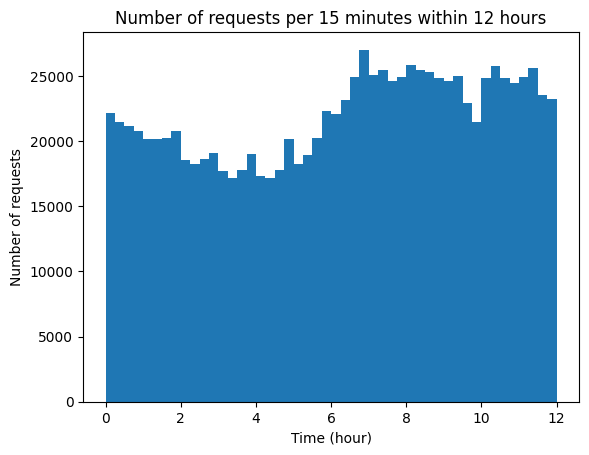

In [9]:
# create histogram plot with binning each 15 minutes
plt.hist(df['time_hour'], bins=48)
plt.xlabel('Time (hour)')
plt.ylabel('Number of requests')
plt.title('Number of requests per 15 minutes within 12 hours')
plt.show()

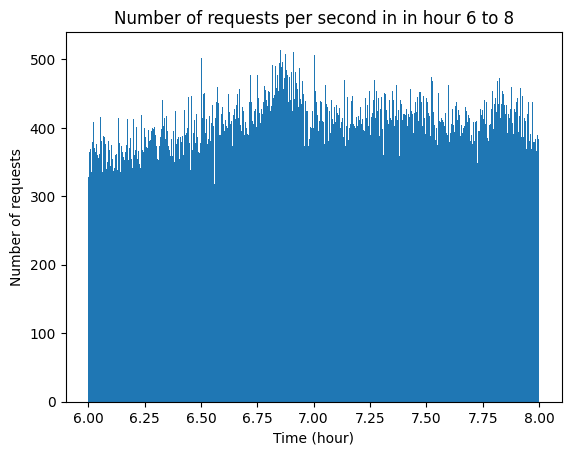

In [10]:
# visualize the data withing interval hour 8 to 9, and binning each 1 minute
plt.hist(df['time_hour'], bins=2 * 60 * 4, range=(6,8))
plt.xlabel('Time (hour)')
plt.ylabel('Number of requests')
plt.title('Number of requests per second in in hour 6 to 8')
plt.show()


## Export the Traffic to Segments

In [13]:
DESIRED_DURATION = 3 * 60  # second
INTERVAL_BIN = 5  # second
START_HOUR = 6
END_HOUR = 8
PEAK_FREQUENCY = 50

# create the data
data = []
target_df = df[(df['time_hour'] >= START_HOUR) & (df['time_hour'] < END_HOUR)]

# rescale the time from 0 to DESIRED_DURATION
time_scale = (target_df['time_hour'] - START_HOUR) / \
    (END_HOUR - START_HOUR) * DESIRED_DURATION
time_scale = time_scale.astype(int)

# aggregate the data based on the interval bin
for i in range(0, DESIRED_DURATION, INTERVAL_BIN):
    time_scale_binned = (time_scale >= i) & (time_scale < i + INTERVAL_BIN)
    frequency = int(time_scale_binned.sum()/INTERVAL_BIN)
    data.append((f'{i}s', frequency, f'{INTERVAL_BIN}s'))


# normalize frequency to wit min and max frequency
if PEAK_FREQUENCY != None:
    max_frequency = max([x[1] for x in data])
    min_frequency = min([x[1] for x in data])
    for i in range(len(data)):
        normalized_frequency = (
            data[i][1] - min_frequency) / (max_frequency - min_frequency) * PEAK_FREQUENCY
        data[i] = (data[i][0], int(normalized_frequency), data[i][2])


# save the data to json
result = pd.DataFrame(data, columns=['time', 'rate', 'duration'])
result.to_json('traffic.json', orient='records')

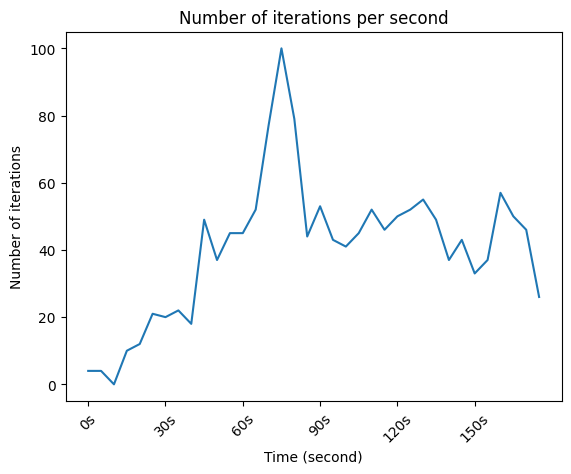

In [14]:
# read traffic.json
df_traffic = pd.read_json('traffic.json')

# visualize the data

plt.plot(df_traffic['time'], df_traffic['rate'])
plt.xlabel('Time (second)')
plt.ylabel('Number of iterations')
plt.title('Number of iterations per second')
plt.xticks(df_traffic['time'][::6], rotation=45)
plt.show()